In [9]:
import sys
import os
import copy
from os import path, getcwd
from collections import OrderedDict
import warnings
import torch

from scipy.stats import wasserstein_distance, kstest, norm, multivariate_normal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd

EVAL_DATASET_SIZE = 4096
#EVAL_DATASET_SIZE = 256
ROOT = 'C:/Mega/trunk/master-thesis'
DATA_PATH = 'F:/master_data/'
CUDA = True

# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

%reload_ext autoreload
%autoreload 2

from precomputation.initialization import *
from misc.naming import *
from inflation.evaluate_model import evaluate_model
from inflation.jupyter_helper import *
from plotting.stats import *
from plotting.transformation import *


folder = 'inflation-04.04_11-55-40-smooth_step-exp'
#folder = 'inflation-04.04_16-54-31-line-exp'
#folder = 'inflation-07.12_11-09-45-sphere-exp_-batch=32'

USED_DIMENSION = 2

EXPERIMENT = 'latent_transformation'
EXPERIMENT = 'full_space'

CONTAINS_RESFLOW = False

DATASET_EXTENSION = create_dataset_extension(folder)

CHECKPOINTS_ROOT = f'{DATA_PATH}/checkpoints/{folder}'

if CONTAINS_RESFLOW:
    MODEL_LIST = ('true', 'ResFlow', 'NICE', 'RealNVP', 'RealNC')
else:
    if USED_DIMENSION > 2:
        MODEL_LIST = ('true', 'RealNVP', 'RealVP', 'NICE')
    else:
        MODEL_LIST = ('true', 'RealNVP', 'NICE')
        
MODELS_WITH_LATENT_INFO = ['RealNVP', 'NICE']
if CONTAINS_RESFLOW:
    MODELS_WITH_LATENT_INFO.insert(0, 'ResFlow')
    
DATASET_NAME = None
SHOW_CASE = False
Gauss_Symbol = '\mathcal{{N}}'
Space_X = '\mathcal{{X}}'
warnings.simplefilter(action='ignore', category=FutureWarning)

In [10]:
all_checkpoints = get_all_checkpoints(CHECKPOINTS_ROOT)
all_checkpoints_unsorted = all_checkpoints

all_checkpoints = sort_all_checkpoints(all_checkpoints, DATA_PATH)

models_to_delete = ['ResFlow', 'RealVP', 'NICE_uniform', 'RealVP_uniform', 'RealNVP_uniform']
for model_to_del in models_to_delete:
    if model_to_del not in MODEL_LIST:
        del all_checkpoints[model_to_del]

    
dimensions, variances = get_all_dimensions_and_variances(all_checkpoints)
dimensions = [USED_DIMENSION]

# to load some standard information
config = load_config(all_checkpoints['NICE'][dimensions[0]][variances[0]], DATA_PATH, verbose=False)

# Dataset Name
ORIGINAL_DATASET_NAME = dataset_to_name(config.dataset)
DATASET_NAME = ORIGINAL_DATASET_NAME
if DATASET_EXTENSION != '':
    DATASET_NAME += ' - ' + DATASET_EXTENSION
    
if USED_DIMENSION > 2:
    Alpha_2d_pdf = 0.005
else:
    Alpha_2d_pdf = {'von Mises': 0.001, 'Smooth Step': 0.01, 'Uniform': 0.005}[ORIGINAL_DATASET_NAME]

In [11]:
#variances = np.array([variances[0], variances[2], variances[5], variances[7]])
#variances = np.array([1e-6, 1e-4])
#variances = variances[:3]
#variances = variances[:-2]

two cases<br>
&emsp; 1. sampled and latent space<br>
&emsp; 2. grid and data space<br>
    &emsp; only in 2D?<br>
    &emsp; slice of 100D <br>
        &emsp;&emsp; Problem: need to match manifold<br>
        &emsp;&emsp; Solution: manifold grid is data and grid along first two dimensions<br>
        &emsp;&emsp; then rotate and evaluate with models<br>
        &emsp;&emsp; then rotate back and plot?<br>

In [12]:
#eval_dataset_size = 50000
eval_dataset_size = 10000
if SHOW_CASE:
    eval_dataset_size = 100000
    
batch_size = 2**15 if USED_DIMENSION == 2 else 2**11
batch_size = int(batch_size)

variances = np.array(variances)
all_models = load_and_sort_all_data(all_checkpoints, variances, dimensions, DATA_PATH, eval_dataset_size=eval_dataset_size, 
                                    data_extension=DATASET_EXTENSION, add_gauss_model=False, experiment=EXPERIMENT, 
                                    batch_size=batch_size, ignore_deflation=True, normalize_realnc=True)
print('\nZeros encountered in log is fine as we look into the entire space which areas with 0 density.')
%matplotlib inline

Loading / Storing Data from
F:/master_data/preloaded_experiments\full_space-smooth_step-\dim2-var-inf.exp
 dim 2 var 0.1  1 
Zeros encountered in log is fine as we look into the entire space which areas with 0 density.


C:/Mega/trunk/master-thesis\src/exp\inflation\jupyter_helper.py:109: UserWarning: This should be reconsidered, when X is not bounded! (Like z ~ N)
  warnings.warn('This should be reconsidered, when X is not bounded! (Like z ~ N)')


[model] [dimensions] [var] ['ambient', 'manifold', ...] [keys] 

------------
$rotate([Z, 0]) + N(0, σ^2)$

In [13]:
def remove_quantile(X, Y, length, alpha):
    # length is the distance to the center. We will use this to cut off data 
    _, right = quantile_finder(length, alpha)
    keep_data = length < right
    
    return X[keep_data], Y[keep_data], keep_data

def compute_anulus(dimensions, alpha):
    annulus_radius = np.sqrt(dimensions)
    # all but this amount of mass lies within the the annulus
    annulus_alpha = alpha
    #annulus_beta = np.sqrt( - 1/3 * np.log(annulus_alpha / 3) )
    annulus_beta = np.sqrt( - 64 * np.log(annulus_alpha / 3) )    

    annulus_left = annulus_radius - annulus_beta
    annulus_right = annulus_radius + annulus_beta
    #print(dimensions, ':', annulus_radius, annulus_left, annulus_right)
    return annulus_left, annulus_right

To plot all axis, we use the procedure: <br>
For one sample $z$ with multiple dimensions:<br>
$a := \measuredangle(z[0], z[1]) $, chosen arbitrarly. The circular mean didn't work. 
Apparently most are some angle b and b + 180°.<br>
$l := $ norm$(z)$<br>
$x := l \cdot \cos(a)$<br>
$y := l \cdot \sin(a)$

In [14]:
def reduce_dim_keep_length_and_angle_2(Z):
    angles = [np.arctan2(Z[:, i], Z[:, i+1]) for i in range(USED_DIMENSION-1)]
    angles = np.array(angles).T
    sin = np.mean(np.sin(angles), axis=1)
    cos = np.mean(np.cos(angles), axis=1)
    angles = np.arctan2(sin, cos)
    
    length = np.linalg.norm(Z, axis=1)

    X = length * np.cos(angles)
    Y = length * np.sin(angles)
    return X, Y, length


ZZ = None
def plot_2d_pdf(manifold_or_ambient, approximated, pd_idx=None, alpha=0.005):
    """
    idx == ambient or manifold
    approximated = True: use approximation for density else use predicted density
    """
    if EXPERIMENT != 'latent_transformation': 
        # lazy exit / we use another function for this
        return 
    
    model_list = list(MODEL_LIST)
    if approximated:
        model_list.remove('RealNC')
        pd_idx = 'approximated'
    log = USED_DIMENSION > 4
    log_label = 'log' if log else '' 
    fig, axs = plt.subplots(nrows=len(variances), ncols=len(model_list)+2, figsize=(4.25*(2+len(model_list)), len(variances)*3.5), 
                            squeeze=False, dpi=150)
    
    for var_idx, var in enumerate(variances):
        colume_idx_offset = 0
        for x_ax, model in enumerate(model_list):
            ax = axs[var_idx, x_ax + colume_idx_offset]
            ax.axis('equal')
            # Data
            data = all_models[model][USED_DIMENSION][var][manifold_or_ambient]
            if model == 'true':
                Z = data['embedded_data'].flatten(1)
                Z = Z.cpu().numpy()
            else:
                Z = data[Z_IDX]
                global ZZ
                ZZ = Z
                if len(Z[0].shape) >= 2:
                    Z = Z.squeeze(1)
            
            X, Y, length = reduce_dim_keep_length_and_angle(Z)
            X, Y, keep_data = remove_quantile(X, Y, length, alpha=alpha)
            
            #X = Z[:,0]
            #Y = Z[:,1]
            #X, Y, keep_data = remove_quantile_old(X, Y, alpha=alpha)
            
            pd = data[pd_idx][keep_data]
            plot_transformation(X, Y, pd, log, ax)
            #all_models['true'][USED_DIMENSION][var]['full_grid'][NONE_EMBEDDED_DATA]
            if model in ['NICE', 'RealNVP']:
                original_pd = all_models['true'][dimensions[0]][var][manifold_or_ambient][PD_IDX][keep_data]
                # add volume changes
                volume = data['volume'][keep_data]
                # negative volume, as we come from the other direction
                true_pd = original_pd# - volume
                colume_idx_offset += 1
                plot_transformation(X, Y, true_pd, log, axs[var_idx, x_ax + colume_idx_offset])
            
        var_label = 0 if var == 0 else f'1e{np.log10(var)}'
        axs[var_idx, 0].set_ylabel(f' σ² = {var_label}', size=13)
        if var_idx == 2:
            ...
            #break

    title_kwargs = dict(y=1.06, size=14)
    axs[0, 0].set_title(f'{log_label} p(X)', **title_kwargs)
    axs[0, 1].set_title('NICE(X)', **title_kwargs)
    axs[0, 2].set_title('orignal NICE(X)', **title_kwargs)
    axs[0, 3].set_title('RealNVP(X)', **title_kwargs)
    axs[0, 4].set_title('orignal RealNVP(X)', **title_kwargs)
    #axs[0, 5].set_title('V(x) of RealNVP(X)', **title_kwargs)
    if approximated is False:
        axs[0, 5].set_title('RealNC(X)', **title_kwargs)
        
    manifold_or_ambient_label = ' | Manifold' if 'manifold' in manifold_or_ambient else ' | inflated' 
    title = f'2D {log_label} PDF for {DATASET_NAME} + Noise | {manifold_or_ambient_label} \n' \
            + f'dim(X) = {USED_DIMENSION} | Ring at center has radius 0.5'
    plt.suptitle(title, size=18, fontweight='bold', y=0.92)
    
    fig.savefig(f'transformations/dim_{USED_DIMENSION}/{DATASET_NAME} {manifold_or_ambient} {pd_idx} {log_label}.png', bbox_inches='tight')

#plot_2d_pdf('ambient', pd_idx=CORRECTED_PD, approximated=False, alpha=alpha)
plot_2d_pdf('ambient', pd_idx=PD_IDX, approximated=False)

In [15]:
#plot_2d_pdf('ambient', pd_idx=CORRECTED_PD, approximated=False, alpha=alpha)

In [16]:
#Im 2D Bereich schauen, ob sich die State Density geändert hat über samplings
#Wesentlich kleinere Variance nehmen?

In [17]:
plot_2d_pdf('manifold_grid', pd_idx=PD_IDX, approximated=False)

----------
# Full Space!

In [20]:
%matplotlib inline
def plot_pdf_in_data_space():
    if EXPERIMENT != 'full_space':
        # lazy exit
        return
    print('plotting')

    model_list = list(MODEL_LIST)
    #model_list = model_list[:3]
    log = USED_DIMENSION > 4
    log_label = ' log' if log else ''
    fig, axs = plt.subplots(nrows=len(variances), ncols=len(model_list), figsize=(4.25 * (2 + len(model_list)), len(variances) * 3.5),
                            squeeze=False, dpi=150)

    for var_idx, var in enumerate(variances):
        #print(np.log10(variances[var_idx]))
        var_label = 0 if var == 0 else f'1e{np.log10(var)}'
        axs[var_idx, 0].set_ylabel(f' σ² = {var_label}', size=13)
        
        colume_idx_offset = 0
        # Data
        data = all_models['true'][USED_DIMENSION][var]['full_grid'][NONE_EMBEDDED_DATA]
        X = data[:, 0]
        Y = data[:, 1]
        # X = data[:, 0, 0, 0]
        # Y = data[:, 0, 0, 1]
        for model_idx, model in enumerate(model_list):
            # if model != 'true':
            #    continue
            ax = axs[var_idx, model_idx]
            ax.margins(0.02)
            
            # densities
            pd = all_models[model][USED_DIMENSION][var]['full_grid'][PD_IDX]
            true_pd = all_models['true'][USED_DIMENSION][var]['full_grid'][PD_IDX]

            # plot Magic
            plot_params = plot_data_space(X, Y, pd, log, ax, var, true_pd, Alpha_2d_pdf)
            
        if var_idx == 2:
            ...
            #break

    title_kwargs = dict(y=1.06, size=14)
    axs[0, 0].set_title(f'{log_label} p(X)', **title_kwargs)
    axs[0, 1].set_title('NICE(X)', **title_kwargs)
    axs[0, 2].set_title('RealNVP(X)', **title_kwargs)
    axs[0, 3].set_title('RealNC(X)', **title_kwargs)

    title = f'2D{log_label} PDF for {DATASET_NAME} + Noise \n' + f'dim(X) = {USED_DIMENSION} | Ring at center has radius 0.5'
    plt.suptitle(title, size=18, fontweight='bold', y=0.92)

    fig.savefig(f'transformations/dim_{USED_DIMENSION}_full_grid/{DATASET_NAME} full_grid{log_label}.png', bbox_inches='tight')
    
    print('Except for sigma=0 we use the maximum of p(x) as maximum. If a model exceeds this, we plot white.')

green_stuff = False
#plot_pdf_in_data_space()

Let $q$ be the learned pdf.<br>
For dim > 2 we take the slice <i>rotate</i>([Manifold + Noise, Noise, 0, ..., 0]).<br>
As the range of the densities could be too big we normalize the density of this slide, i.e. $\int p(\textit{rotate}([x, y, 0, ....])) dxdy = 1$.<br>
For the approximation of this integral we use the grid that we want to plot and assign a probability to every cell of the grid by $Q(a) := q(a) \cdot \text{area(a)}$, where $a$ is a point on the grid.<br>
Let $Q_i$ be the normalized probability ordered by their value.
As the minimum color value I choose $q_N$ for $N:= \arg \max_N \sum_{i=0}^N Q_i > 99\%$.<br>
In words: for the minimum plotted value we choose that value that is just still responsible for 99% of the mass.<br><br>
Note that we account for the probability that comes from the dimensions with $0$ as value.

---------
# Plot of Everything

plotting
fix DPI!
(954306, 2)
(954306, 2)
(973674, 2)
(1180137, 2)
(1760607, 2)
Except for sigma=0 we use the maximum of true p(x) as maximum for all models. If a model exceeds this, we plot white.
Latent plots have the norm preserved!
done


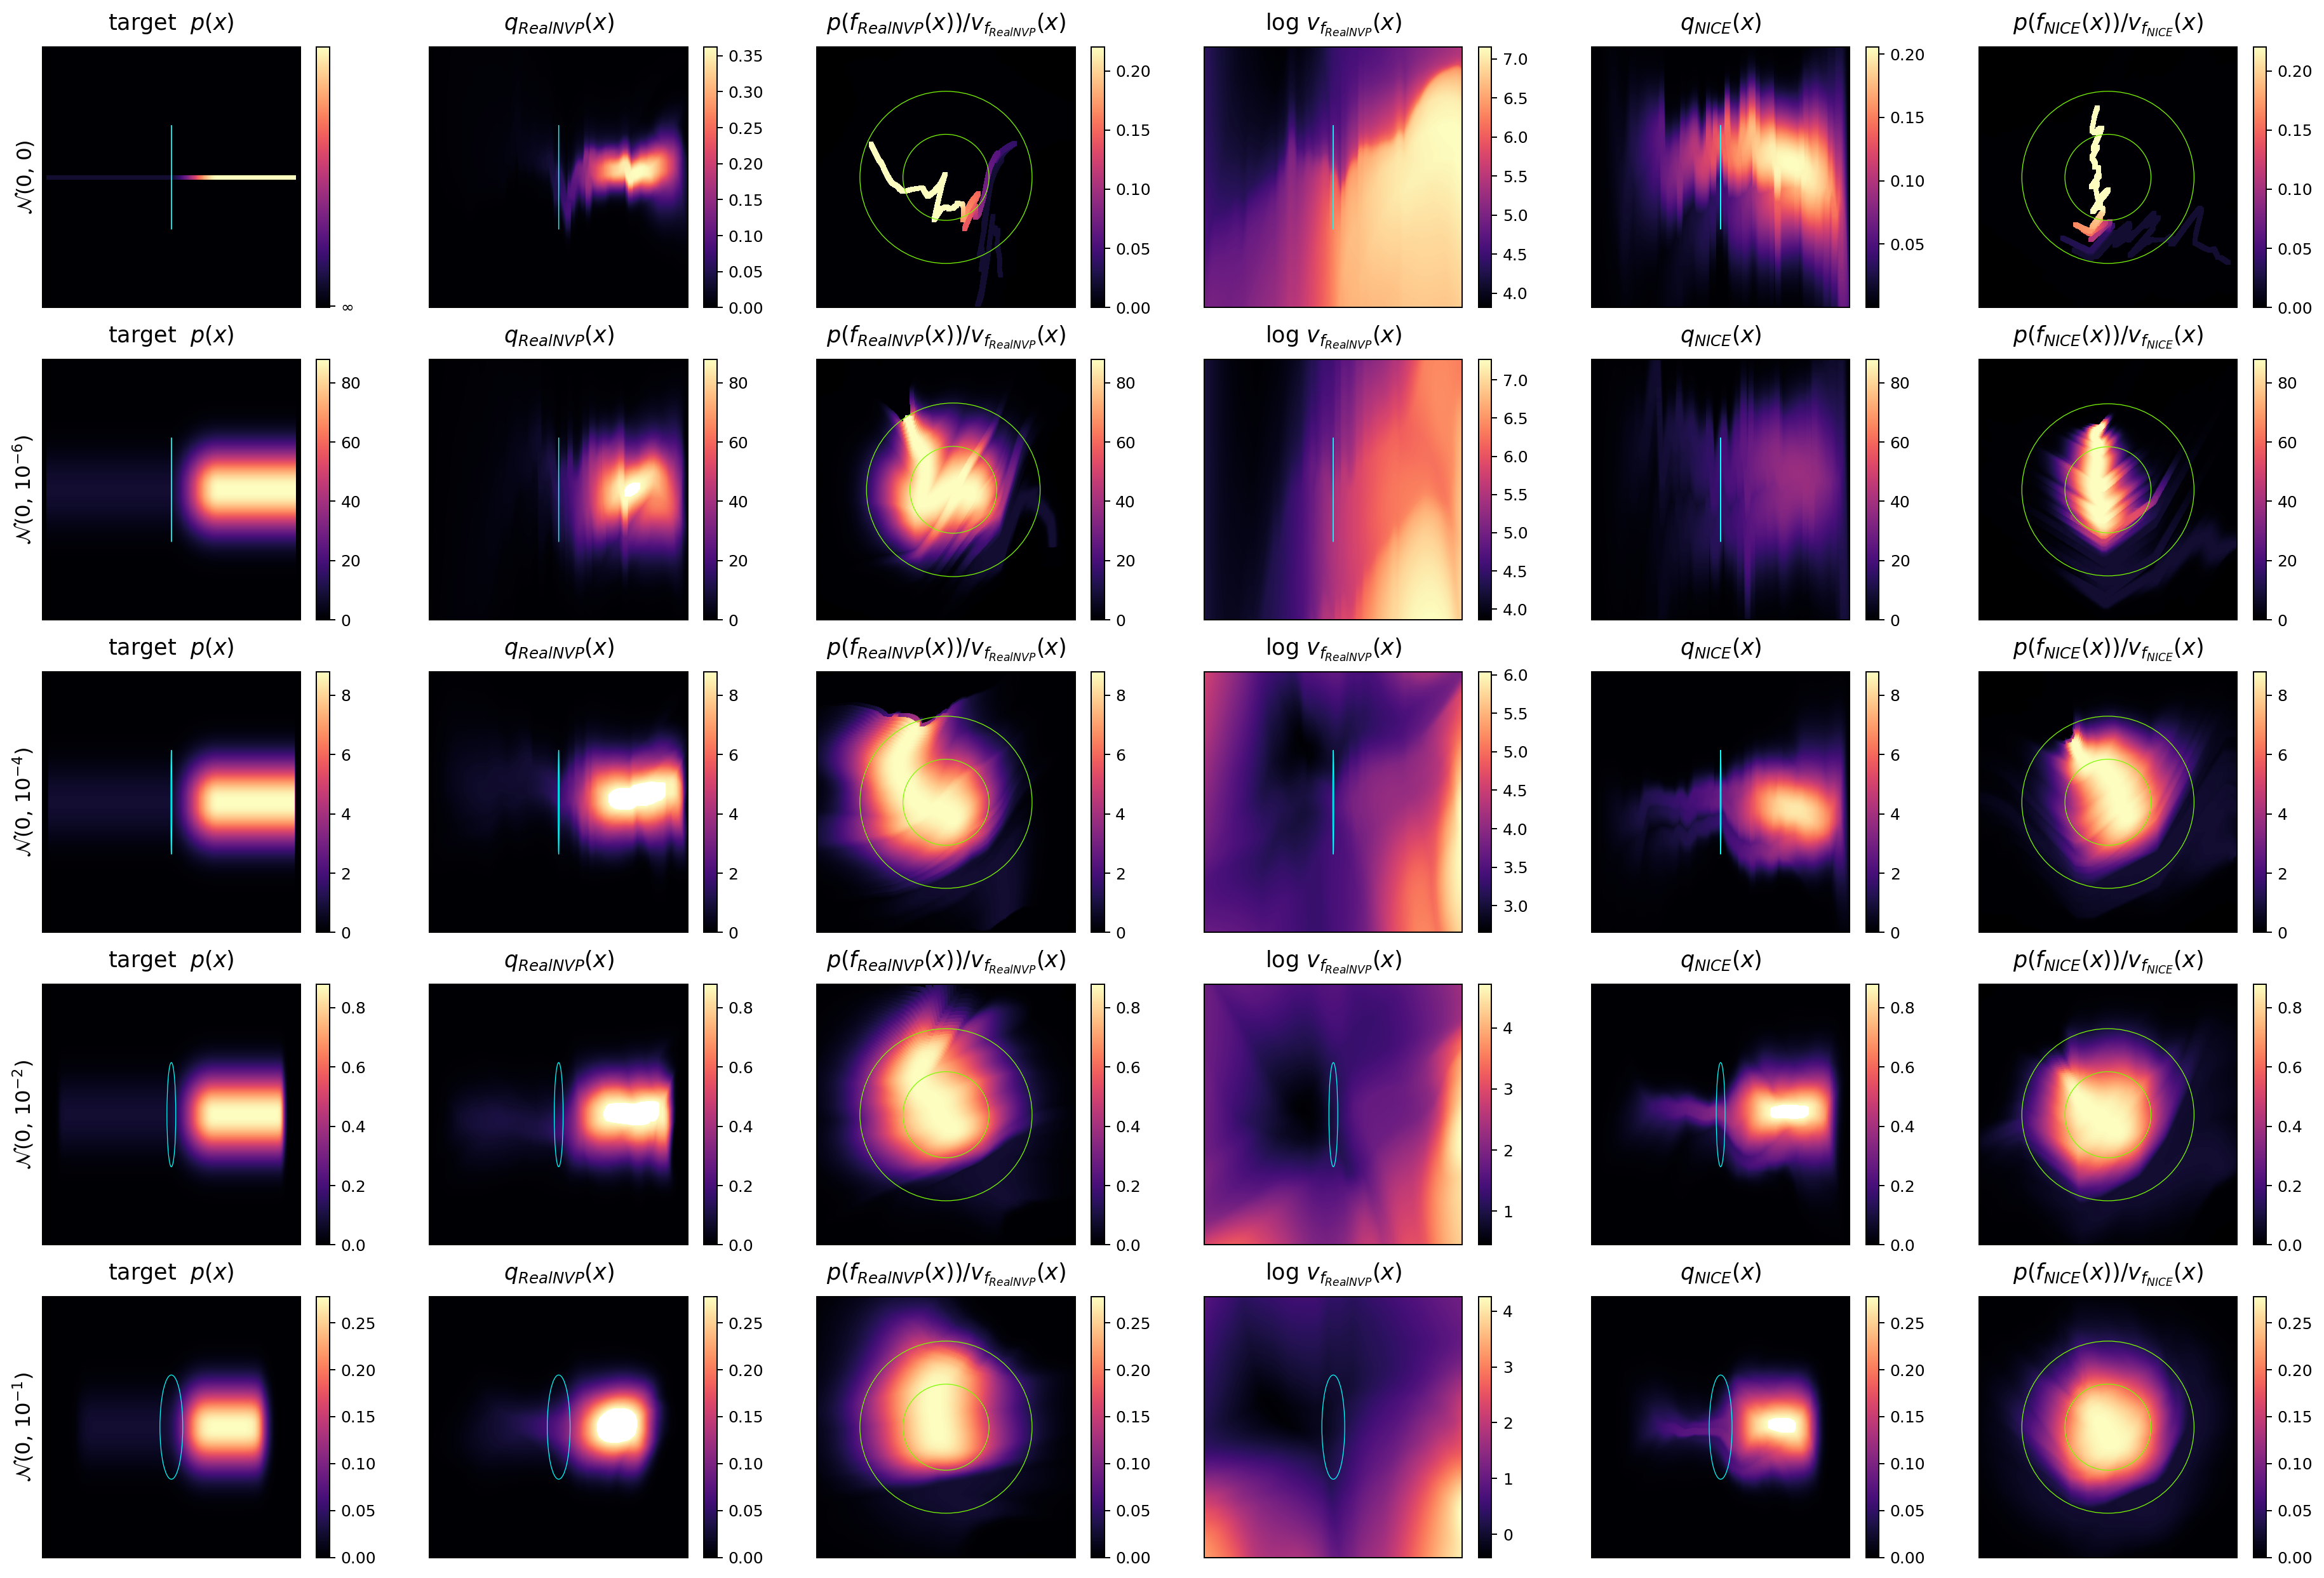

In [72]:
#%matplotlib inline
        
def plot_pdf_in_data_space(with_latent_space=True, plot_circle=True, subdir=''):
    if EXPERIMENT != 'full_space':
        # lazy exit
        return
    print('plotting')
    global green_stuff, Debug, Debug_Remove_All_But
    
    model_list = list(MODEL_LIST)
    #model_list.insert(3, 'volume')
    #model_list = model_list[:3]
    log = USED_DIMENSION > 4
    log_label = ' log' if log else ''
    # true data, NICE, latent NICE, RealNVP, latent RealNVP, V(x), RealNC
    needed_cols = len(model_list) + 3 if with_latent_space else len(model_list)
    if CONTAINS_RESFLOW:
        needed_cols += 2
    print('fix DPI!')
    DPI = 180 #180 if USED_DIMENSION > 2 else 180
    #scatter_size = 0.8
    scatter_size = 8
    fig, axs = plt.subplots(nrows=len(variances), ncols=needed_cols, figsize=(4.25 * needed_cols, len(variances) * 3.5),
                            squeeze=False, dpi=DPI)

    for var_idx, var in enumerate(variances):
        #print(np.log10(variances[var_idx]))
        if Debug and (var == 0 or var_idx != 2): continue # var == 0 or 
        
        dataset = all_models['true'][USED_DIMENSION][var]['full_grid']['dataset']
        #axs[var_idx, 0].set_ylabel(f' σ² = {var_label}\ny gran = {dataset.y_granularity_of_grid_plot}', size=13)
        axs[var_idx, 0].set_ylabel(f'${Gauss_Symbol}$(0, {var_to_label(var)})', size=13)

        colume_idx_offset = 0
        # Data
        true_pd = all_models['true'][USED_DIMENSION][var]['full_grid'][PD_IDX]
        data = all_models['true'][USED_DIMENSION][var]['full_grid'][NONE_EMBEDDED_DATA]  # [EMBEDDED_DATA].squeeze(1).squeeze(1)
        print(data.shape)
        data_X, data_Y = data[:, 0], data[:, 1]
        data_X, data_Y, true_pd = data_X[1::Debug_Remove_All_But], data_Y[1::Debug_Remove_All_But], true_pd[1::Debug_Remove_All_But]
        
        col_offset = 0
        #plot_params = None, None
        for model_idx, model in enumerate(model_list):
            if Debug and model not in ['true']: continue
            if Talk:    
                print(var, model)
            ax = axs[var_idx, model_idx+col_offset]
            ax.margins(0.02)
            add_circle_by_var(ax, var)
            
            # normal densities plotting
            pd = all_models[model][USED_DIMENSION][var]['full_grid'][PD_IDX]
            pd = pd[1::Debug_Remove_All_But]
            
            data_X_, data_Y_, pd_ = remove_additional_granularity_points(data_X, data_Y, pd, var, dataset)
            plot_params = plot_data_space(data_X_, data_Y_, pd_, log, ax, var, true_pd, dataset,
                                          Alpha_2d_pdf, model, scatter_size=scatter_size, plot_circle=plot_circle, green_stuff=green_stuff)
                
            # transformation plotting
            if with_latent_space and model in MODELS_WITH_LATENT_INFO:
                # use norm and so on?
                Z = all_models[model][USED_DIMENSION][var]['full_grid'][Z_IDX]
                if USED_DIMENSION == 2:  Z = Z.squeeze(1)
                
                # rotate back
                Z = dataset.rotation_matrix.T @ Z.T
                Z = Z.T
                
                #latent_X, latent_Y = Z[:, 0], Z[:, 1]
                Z = Z[1::Debug_Remove_All_But]
                
                col_offset += 1
                # plot Magic
                X, Y, length, Z_keeper = reduce_dim_keep_length_and_angle(Z, max_length=3)
                used_true_pd = true_pd[Z_keeper]
                
                latent_ax = axs[var_idx, model_idx+col_offset]
                plot_data_space(X, Y, used_true_pd, log, latent_ax, var, true_pd, dataset,
                                alpha=0.1, model=model, v_min=plot_params[0], v_max=plot_params[1], 
                                scatter_size=scatter_size, plot_circle=False, green_stuff=green_stuff)
                add_circle(latent_ax, 1, color='lawngreen'), add_circle(latent_ax, 2, color='lawngreen')
                
            # volume element
            if with_latent_space and model in ['RealNVP', 'ResFlow']:
                volume = all_models[model][USED_DIMENSION][var]['full_grid'][VOLUME_IDX]
                volume = volume[1::Debug_Remove_All_But]
            
                col_offset += 1
                volume_ax = axs[var_idx, model_idx+col_offset]
                #vmin_max=(None, np.log(10) + pd.max())
                plot_transformation(data_X, data_Y, volume, log=True, ax=volume_ax, vmin_max=(None, None), scatter_size=1.5*scatter_size)
                add_circle_by_var(volume_ax, var)
            if model != 'true':
                ax.set_xlim(axs[var_idx, 0].get_xlim())
                ax.set_ylim(axs[var_idx, 0].get_ylim())
            
    if with_latent_space:
        labels = [f'target {log_label} $p(x)$', f'$q_{{RealNVP}}(x)$', f'$p(f_{{RealNVP}}(x)) / v_{{f_{{RealNVP}}}}(x)$', 
                  f'log $v_{{f_{{RealNVP}}}}(x)$', f'$q_{{NICE}}(x)$', '$p(f_{{NICE}}(x)) / v_{{f_{{NICE}}}}(x)$'] # , 'RealNC'
    else:
        labels = [f'target {log_label} p(X)'] + list(MODEL_LIST)[1:]
        
    if CONTAINS_RESFLOW:
        labels.insert(1, 'ResFlow'), labels.insert(2, 'latent ResFlow'), labels.insert(3, f'{log_label} volume ResFlow')
        
    for i, label in enumerate(labels):
        for j in range(len(axs)):
            axs[j, i].set_title(label, y=1.03, size=14)
            axs[j, i].autoscale(tight=True)
        
    for x in range(len(axs)):
        if with_latent_space:
            axs[x, 2].axis('equal'), axs[x, 5].axis('equal')
        else:
            ...#axs[x, 0].axis('equal'), axs[x, 1].axis('equal'), axs[x, 2].axis('equal')
    
    title = f'2D{log_label} PDF for {DATASET_NAME} + Noise \n' + f'dim(X) = {USED_DIMENSION} | '+\
              f'Rings at center, latent ring r=0.5, data ring r=σ^(1/3) |'
    #plt.suptitle(title, size=18, fontweight='bold', y=0.92)
    res_flow_add = ' with resFlow' if CONTAINS_RESFLOW else ''
    used_dir = f'transformations/dim_{USED_DIMENSION}_full_grid/{subdir}/'
    os.makedirs(used_dir, exist_ok=True)
    fig.savefig(f'{used_dir}{DATASET_NAME} full_plot{log_label}{res_flow_add}.png', bbox_inches='tight')
    
    used_dir = f'{used_dir}/all/{DATASET_NAME}/'
    os.makedirs(used_dir, exist_ok=True)
    for y in range(len(axs)):
        for x in range(len(axs[y])):
            extent = full_extent_all(axs[y,x]).transformed(fig.dpi_scale_trans.inverted())
            fig.savefig(f'{used_dir}{y}-{x}.png', bbox_inches=extent)
            
    print('Except for sigma=0 we use the maximum of true p(x) as maximum for all models. If a model exceeds this, we plot white.')
    print('Latent plots have the norm preserved!')
    return axs
    
    
green_stuff = False
Debug = False
Debug_Remove_All_But = 1  # 1::Debug_Remove_All_But 
Talk = False  # forgot normal expression
axs = plot_pdf_in_data_space(with_latent_space=True, plot_circle=False, subdir='used')
print('done')

In [ ]:
#plot_pdf_in_data_space(with_latent_space=True, plot_circle=True)

------------
# Latent Transformation

start
plotting
X contains Manifold + 2 std devs


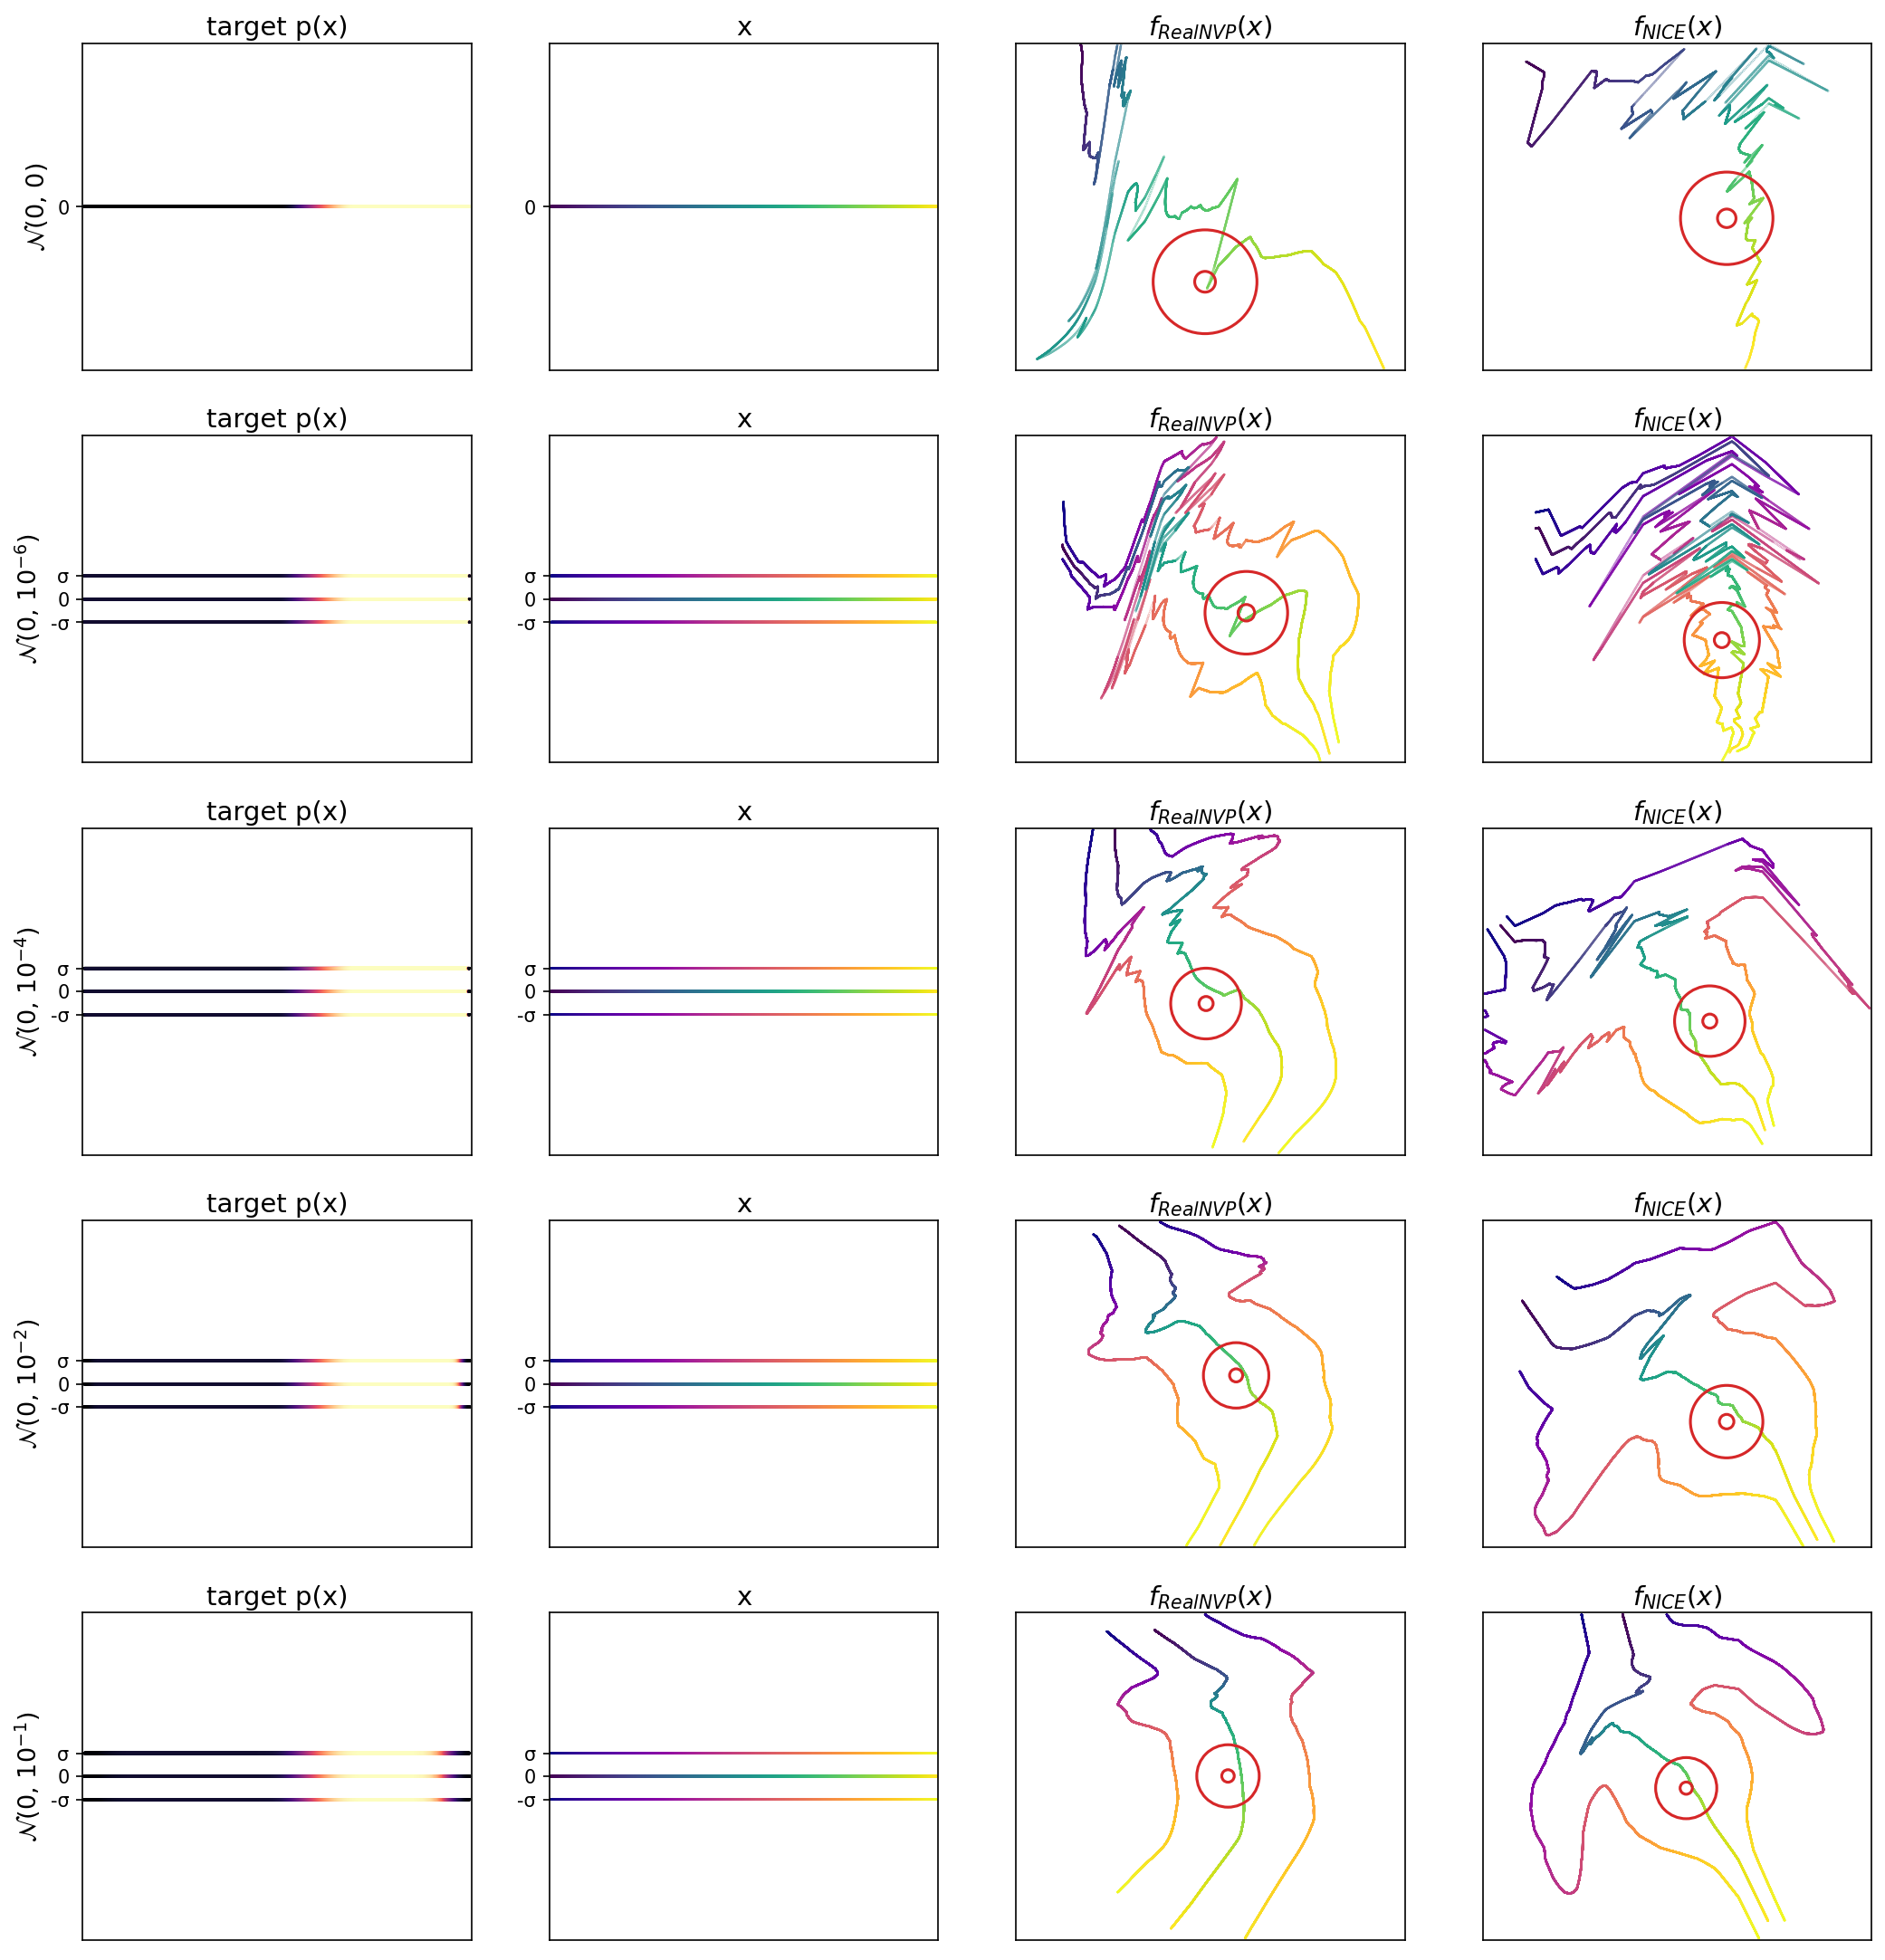

done


In [60]:
def remove_far_away_points(X, Y, color, alpha):
    # removes the points that are furthest away
    # as we can keep all points that are within the drawing square, we can keep them though
    length_sq = X ** 2 + Y ** 2
    _, longest = quantile_finder(length_sq, alpha)
    keeper = length_sq < longest

    keep_X, keep_Y = X[keeper], Y[keeper]
    max_v = max(keep_X.max(), keep_Y.max())
    min_v = min(keep_X.min(), keep_Y.min())

    keep_X = np.logical_and(X >= min_v, X <= max_v)
    keep_Y = np.logical_and(Y >= min_v, Y <= max_v)
    keeper = np.logical_and(keep_X, keep_Y)

    return X[keeper], Y[keeper], color[keeper], keeper


def get_manifold_keeper(y_data):
    return y_data == 0


def plot_latent_transformation():
    if EXPERIMENT != 'full_space':
        return  # lazy exit
    print('plotting')

    global DPI, Debug
    model_list = MODELS_WITH_LATENT_INFO
    per_model_factor = 2 if USED_DIMENSION > 2 else 1
    needed_cols = len(model_list) * per_model_factor + 2
    fig, axs = plt.subplots(nrows=len(variances), ncols=needed_cols,
                            figsize=(4.25 * needed_cols, len(variances) * 3.7),
                            squeeze=False, dpi=DPI)

    for var_idx, var in enumerate(variances):
        # print(np.log10(variances[var_idx]))
        if Debug and (var == 0 or var_idx > 1): continue
        
        std_dev = 0 if var == 0 else np.sqrt(var)
        ax_true = axs[var_idx, 0]
        ax_origin = axs[var_idx, 1] # σ²
        
        ax_origin.std_dev, ax_true.std_dev = std_dev, std_dev
        
        ax_true.set_ylabel(f'{gauss_symbol()}(0, {var_to_label(var)})', size=13)

        # Data
        dataset = all_models['true'][USED_DIMENSION][var]['full_grid']['dataset']
        density = dataset.densities['inflated_manifold_log_pd']
        data = all_models['true'][USED_DIMENSION][var]['full_grid'][NONE_EMBEDDED_DATA]
        data_X, data_Y = data[:, 0], data[:, 1]

        # which points to keep
        manifold_y_keeper = get_manifold_keeper(data_Y)
        #line_keeper = np.logical_or(get_nth_std_dev_keeper(data_Y, 0.5, std_dev, dataset),
        #                            get_nth_std_dev_keeper(data_Y, 1, std_dev, dataset))
        line_keeper = get_nth_std_dev_keeper(data_Y, 1, std_dev, dataset)
        manifold_y_keeper = np.logical_or(manifold_y_keeper, line_keeper)

        manifold_x_bounds = dataset.get_manifold_bounds()
        manifold_x_keeper = np.logical_and(data_X >= manifold_x_bounds[0] - 2 * std_dev,
                                           data_X <= manifold_x_bounds[1] + 2 * std_dev)
        data_keeper = np.logical_and(manifold_y_keeper, manifold_x_keeper)

        data_X, data_Y, density = data_X[data_keeper], data_Y[data_keeper], density[data_keeper]

        # PD
        # ax_true.patch.set_facecolor('black')
        dens_color = np.exp(density)
        mani_keeper = get_manifold_keeper(data_Y)
        #ax_true.scatter(data_X[mani_keeper], data_Y[mani_keeper], c=color[mani_keeper], s=0.3, cmap='magma', marker='o')
        ax_true.scatter(data_X, data_Y, c=dens_color, s=0.3, cmap='magma', marker='o')

        # coloring
        for idcs, cmap, size in [(get_nth_std_dev_keeper(data_Y, 1, std_dev, dataset), 'plasma', 0.05),
                            (get_manifold_keeper(data_Y), 'viridis', 0.2),]:
                           #(get_nth_std_dev_keeper(data_Y, 1, std_dev, dataset), 'summer')]:
            ax_origin.scatter(data_X[idcs], data_Y[idcs], c=data_X[idcs], s=size, marker='o', cmap=cmap)

        """x location determins color. left most is 0, rightmost is 1. 
        That is it. => how to assign one color location? => ax.scatter(c=x_location)"""
        for model_idx, model in enumerate(model_list):
            Z = all_models[model][USED_DIMENSION][var]['full_grid'][Z_IDX]
            pd = all_models[model][USED_DIMENSION][var]['full_grid'][PD_IDX]
            if USED_DIMENSION == 2:  Z = Z.squeeze(1)
            Z = Z[data_keeper]
            pd = pd[data_keeper]

            def plot_latent_points(lat_X, lat_Y, l_ax, argmin_norm, argmax_pd):
                """Plots the latent points"""
                # lat_X, lat_Y = lat_X[data_keeper], lat_Y[data_keeper]
                _, _, _, keeper = remove_far_away_points(lat_X, lat_Y, color=data_X, alpha=0.05)

                for idcs, cmap, size in [(get_nth_std_dev_keeper(data_Y, 1, std_dev, dataset), 'plasma', 0.05),
                                   (get_manifold_keeper(data_Y), 'viridis', 0.02),]: # ,
                                   #(get_nth_std_dev_keeper(data_Y, 1, std_dev, dataset), 'summer', 0.01)
                    line_keeper = np.logical_and(idcs, keeper)
                    r_lat_X, r_lat_Y, color = lat_X[line_keeper], lat_Y[line_keeper], data_X[line_keeper]
                    l_ax.scatter(r_lat_X, r_lat_Y, c=color, s=0.01, marker='o', cmap=cmap, alpha=2)

                #l_ax.scatter(lat_X[argmin_norm], lat_Y[argmin_norm], c=get_model_color(model), s=50, marker="x")
                #l_ax.scatter(lat_X[argmax_pd], lat_Y[argmax_pd], c=get_model_color(model), s=50, marker=".")

            # normed
            norm_latent_X, norm_latent_Y, length, _ = reduce_dim_keep_length_and_angle(Z)

            # argmin points
            argmin_norm = argmax_pd = None
            if False:
                argmin_norm = length.argmin()
                argmax_pd = pd.argmax()

                ax_origin.scatter(data_X[argmin_norm], data_Y[argmin_norm], c=get_model_color(model), s=50, marker="x",
                                  label=f'{model}')
                ax_origin.scatter(data_X[argmax_pd], data_Y[argmax_pd], c=get_model_color(model), s=50, marker=".")

            # normed plot
            if USED_DIMENSION > 2:
                plot_latent_points(norm_latent_X, norm_latent_Y, axs[var_idx, model_idx * per_model_factor + 3],
                                   argmin_norm, argmax_pd)

            # sliced plot
            latent_X, latent_Y = Z[:, 0], Z[:, 1]
            plot_latent_points(latent_X, latent_Y, axs[var_idx, model_idx * per_model_factor + 2], argmin_norm,
                               argmax_pd)

        #ax_origin.legend()
        #ax_true.scatter(None, None, s=50, marker="x", color='k', label='argmin norm')
        #ax_true.scatter(None, None, s=50, marker=".", color='k', label='argmax density')
        #ax_true.legend()

    for x in range(len(axs)):
        for y in range(len(axs[x])):
            ax = axs[x, y]
            ax.margins(0.005)

            ax.set_xticks([])
            ax.set_yticks([])
            # Circle
            if y in [2, 3]:
                ax.axis('equal')
                circle = plt.Circle((0, 0), 0.5, color='tab:red', fill=False, alpha=1, linewidth=1.5)
                ax.add_patch(circle)
                circle = plt.Circle((0, 0), 0.1, color='tab:red', fill=False, alpha=1, linewidth=1.5)
                ax.add_patch(circle)
            else:
                var = variances[x]
                std_dev = 1e-3 if var == 0 else var ** 0.5
                
                circle = plt.Circle((0, 0), 7*std_dev, color='tab:red', fill=False, alpha=0, linewidth=1.5)
                ax.add_patch(circle)
                if var > 0:
                    ax.set_yticks([-std_dev, 0, std_dev])
                    ax.set_yticklabels(['-σ', '0', 'σ'])
                else:
                    ax.set_yticks([0])
                    ax.set_yticklabels(['0'])

    if USED_DIMENSION == 2:
        labels = ['target p(x)', 'x', '$f_{{RealNVP}}(x)$', '$f_{{NICE}}(x)$']
    else:
        labels = ['target p(x)', 'x', 'sliced NICE(x)', 'norm preserved NICE(x)',
                  'sliced RealNVP(x)', 'norm preserved RealNVP(x)']
        if CONTAINS_RESFLOW:
            labels.insert(2, 'sliced ResFlow(X)'), labels.insert(3, 'norm preserved ResFlow(X)')

    for i, label in enumerate(labels):
        for j in range(len(axs)):
            axs[j, i].set_title(label, y=0.99, size=14)

    title = f'Latent transformation of {DATASET_NAME}\n' + f'Manifold and first std dev. (For σ=0 it\'s {dataset.y_granularity_of_grid_plot})\n' + f'dim(X) = {USED_DIMENSION} | Ring at center has radius 0.5 and 0.1'
    # plt.suptitle(title, size=18, fontweight='bold', y=0.93)
    print('X contains Manifold + 2 std devs')
    plt.show()
    res_flow_add = ' with resFlow' if CONTAINS_RESFLOW else ''
    used_dir = f'transformations/dim_{USED_DIMENSION}_full_grid/used/'
    #fig.savefig(f'{used_dir}/{DATASET_NAME} latent transformation{res_flow_add}.png',
    #            bbox_inches='tight')
    
    used_dir = f'{used_dir}/trans/{DATASET_NAME}/'
    os.makedirs(used_dir, exist_ok=True)
    for y in range(len(axs)):
        #if y != 1: continue
        for x in range(len(axs[y])):
            #if x != 2: continue
            extent = full_extent_trans(axs[y,x]).transformed(fig.dpi_scale_trans.inverted())
            fig.savefig(f'{used_dir}{y}-{x}.png', bbox_inches=extent)
            #break
    
    
def full_extent_trans(ax):
    bbox = ax.get_window_extent()
    
    items = [ax, *ax.get_yticklabels()]
    bbox = Bbox.union([item.get_window_extent() for item in items])
        
    if len(ax.get_yticklabels()) > 0:
        bbox = Bbox.from_bounds(bbox.x0 + 2, bbox.y0 - 2, bbox.width + 2, bbox.height + 5)
    else:
        bbox = Bbox.from_bounds(bbox.x0 - 1, bbox.y0 - 2, bbox.width + 4, bbox.height + 5)
    return bbox


DPI = 150
Debug = False
print('start')
plot_latent_transformation()
print('done')